# Regression Track — Real Estate Price Prediction
**23CSE301 Machine Learning Capstone — Review 1**

Pipeline: data loading → EDA → cleaning & feature engineering → 10 regression algorithms →
hyperparameter tuning → evaluation (R², RMSE, MAE, 5-fold CV) → visualisation.

> **Note on data leakage:** `price_per_sqft` is mathematically derived as `price / size_in_sqft`.
> Since `price` is our target, keeping `price_per_sqft` as a feature would leak the answer directly
> into the model (near-perfect, meaningless R²). We deliberately **drop it before modelling** and
> document this decision here, as required by the EDA insight-commentary rubric.


In [4]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import PolynomialFeatures
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

RANDOM_STATE = 42
sns.set_style('whitegrid')
sns.set_palette('colorblind')
plt.rcParams['figure.figsize'] = (8, 5)


## Section A — Dataset Loading & EDA

### A1. Dataset loading & audit
Load the CSV, inspect shape, dtypes, missing values, and target distribution.

In [5]:
DATA_PATH = "../data/properties_data.csv"
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
df.head()


Shape: (1905, 38)


,id,neighborhood,latitude,longitude,price,size_in_sqft,price_per_sqft,no_of_bedrooms,no_of_bathrooms,quality,...,private_pool,security,shared_gym,shared_pool,shared_spa,study,vastu_compliant,view_of_landmark,view_of_water,walk_in_closet
0,5528049,Palm Jumeirah,25.113208,55.138932,2700000,1079,2502.32,1,2,Medium,...,False,False,True,False,False,False,False,False,True,False
1,6008529,Palm Jumeirah,25.106809,55.151201,2850000,1582,1801.52,2,2,Medium,...,False,False,True,True,False,False,False,False,True,False
2,6034542,Jumeirah Lake Towers,25.063302,55.137728,1150000,1951,589.44,3,5,Medium,...,False,True,True,True,False,False,False,True,True,True
3,6326063,Culture Village,25.227295,55.341761,2850000,2020,1410.89,2,3,Low,...,False,False,False,False,False,False,False,False,False,False
4,6356778,Palm Jumeirah,25.114275,55.139764,1729200,507,3410.65,0,1,Medium,...,False,True,True,True,True,False,False,True,True,False


In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1905 entries, 0 to 1904
Data columns (total 38 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   1905 non-null   int64  
 1   neighborhood         1905 non-null   object 
 2   latitude             1905 non-null   float64
 3   longitude            1905 non-null   float64
 4   price                1905 non-null   int64  
 5   size_in_sqft         1905 non-null   int64  
 6   price_per_sqft       1905 non-null   float64
 7   no_of_bedrooms       1905 non-null   int64  
 8   no_of_bathrooms      1905 non-null   int64  
 9   quality              1905 non-null   object 
 10  maid_room            1905 non-null   bool   
 11  unfurnished          1905 non-null   bool   
 12  balcony              1905 non-null   bool   
 13  barbecue_area        1905 non-null   bool   
 14  built_in_wardrobes   1905 non-null   bool   
 15  central_ac           1905 non-null   b

In [7]:
# Missing value audit
missing = df.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]
print("Columns with missing values:")
print(missing if len(missing) else "None found.")


Columns with missing values:
None found.


In [8]:
# Convert TRUE/FALSE amenity columns to 0/1 if read in as strings/bools
bool_cols = ['maid_room','unfurnished','balcony','barbecue_area','built_in_wardrobes',
             'central_ac','childrens_play_area','childrens_pool','concierge','covered_parking',
             'kitchen_appliances','lobby_in_building','maid_service','networked','pets_allowed',
             'private_garden','private_gym','private_jacuzzi','private_pool','security',
             'shared_gym','shared_pool','shared_spa','study','vastu_compliant',
             'view_of_landmark','view_of_water','walk_in_closet']
bool_cols = [c for c in bool_cols if c in df.columns]

for c in bool_cols:
    if df[c].dtype == object:
        df[c] = df[c].astype(str).str.strip().str.upper().map({'TRUE': 1, 'FALSE': 0})
    else:
        df[c] = df[c].astype(int)

print("Boolean columns converted:", len(bool_cols))
df[bool_cols].sum().sort_values(ascending=False)


Boolean columns converted: 28


shared_pool            1404
balcony                1371
built_in_wardrobes     1361
central_ac             1301
shared_gym             1258
unfurnished            1222
covered_parking        1178
kitchen_appliances      691
concierge               679
security                671
view_of_water           654
childrens_play_area     639
pets_allowed            567
view_of_landmark        397
walk_in_closet          290
maid_room               275
barbecue_area           269
lobby_in_building       201
shared_spa              194
study                   193
childrens_pool          161
maid_service            157
networked               118
private_jacuzzi          97
vastu_compliant          88
private_pool             82
private_garden           32
private_gym              15
dtype: int64

count    1.905000e+03
mean     2.085830e+06
std      2.913200e+06
min      2.200000e+05
25%      8.900000e+05
50%      1.400000e+06
75%      2.200000e+06
max      3.500000e+07
Name: price, dtype: float64


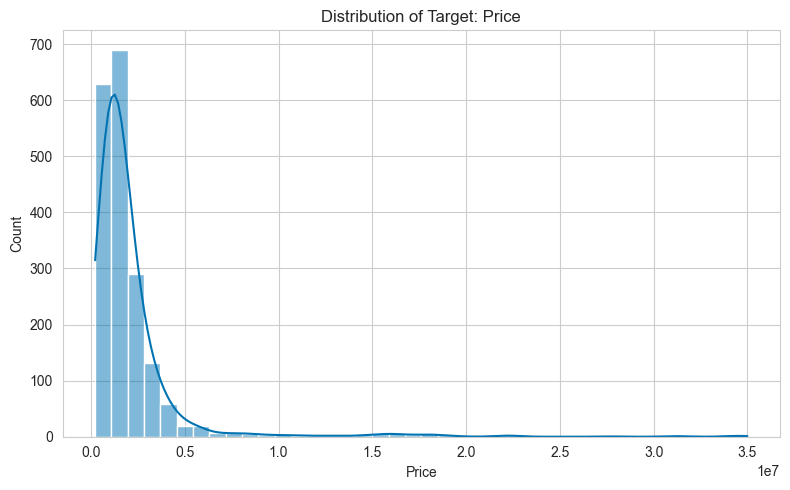

In [12]:
# Target distribution
print(df['price'].describe())
sns.histplot(df['price'], kde=True, bins=40)
plt.title('Distribution of Target: Price')
plt.xlabel('Price'); plt.ylabel('Count')
plt.tight_layout()
plt.show()


**Observation:** *(fill in after running — note skew, presence of high-value outliers, whether a log-transform of price looks warranted.)*

### A2. EDA Visualisations

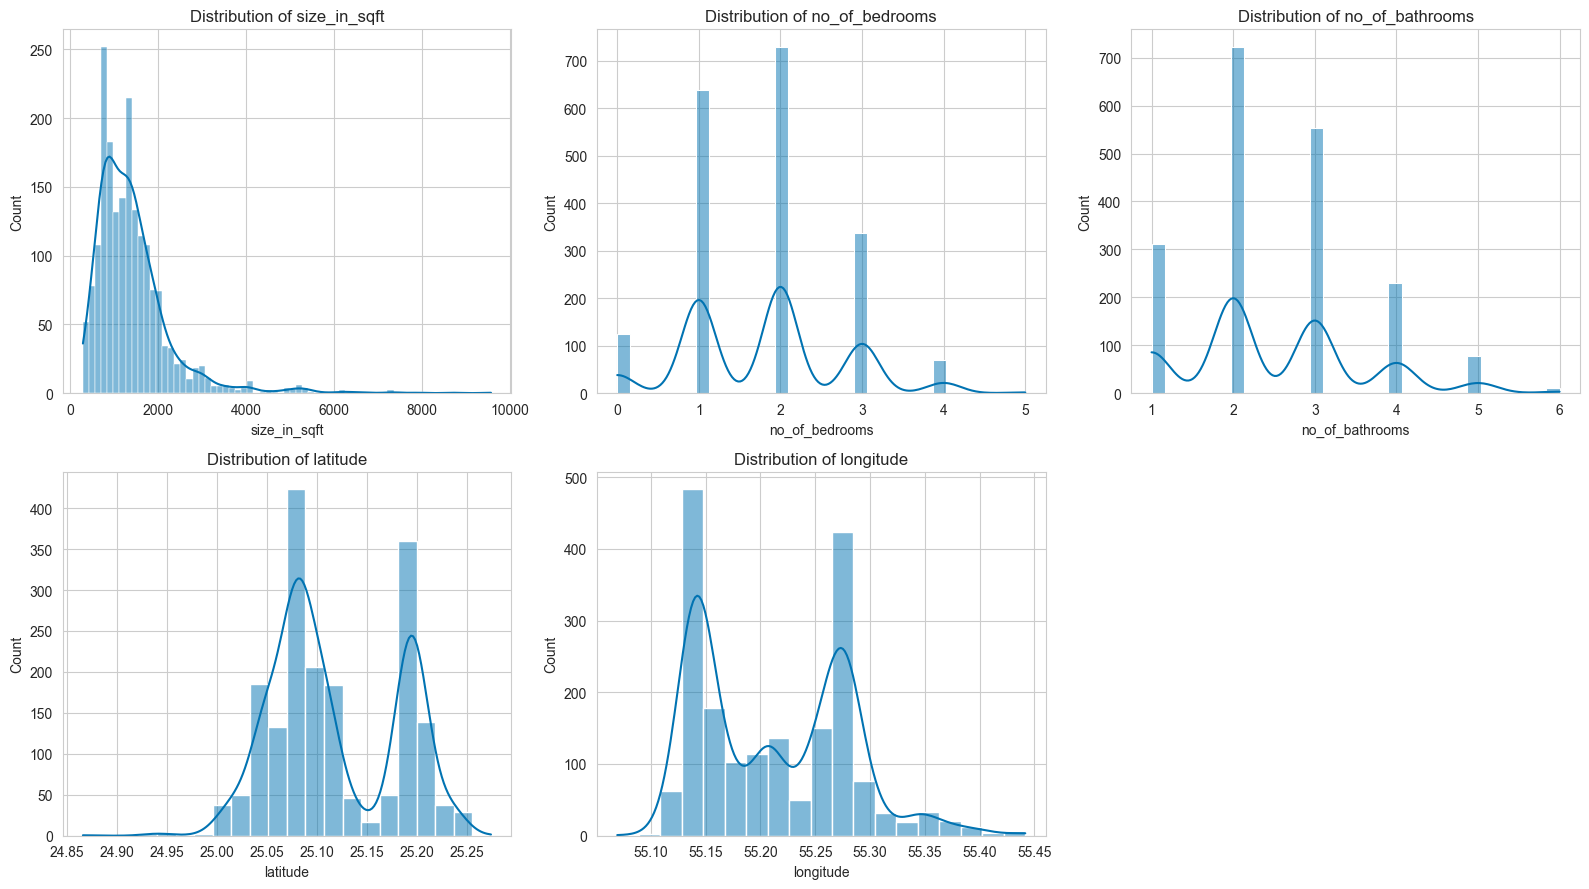

In [14]:
num_cols = ['size_in_sqft', 'no_of_bedrooms', 'no_of_bathrooms', 'latitude', 'longitude']
num_cols = [c for c in num_cols if c in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, c in enumerate(num_cols):
    sns.histplot(df[c].dropna(), kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {c}')
for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()


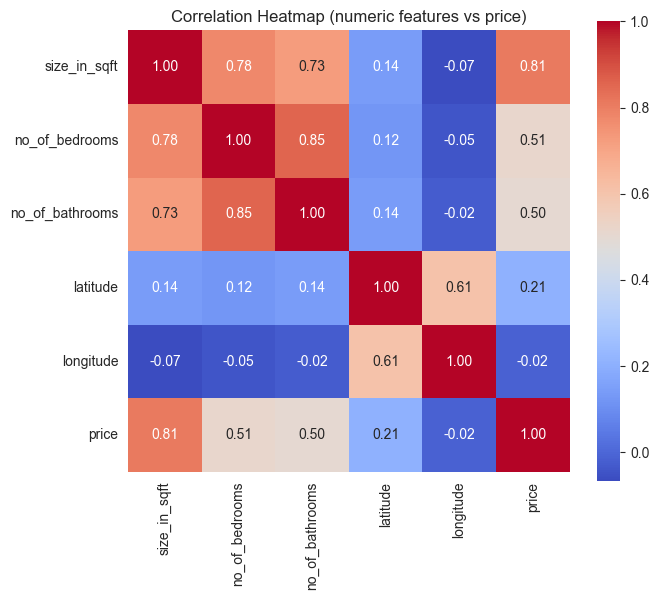

In [15]:
corr_cols = num_cols + ['price']
plt.figure(figsize=(7,6))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation Heatmap (numeric features vs price)')
plt.tight_layout()
plt.show()


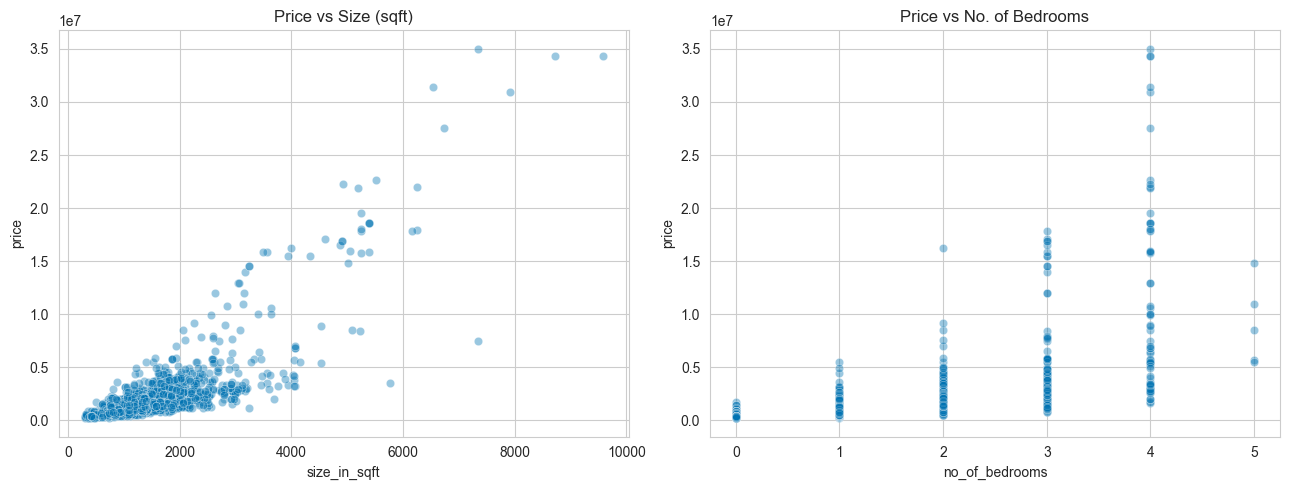

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))
sns.scatterplot(data=df, x='size_in_sqft', y='price', alpha=0.4, ax=axes[0])
axes[0].set_title('Price vs Size (sqft)')

sns.scatterplot(data=df, x='no_of_bedrooms', y='price', alpha=0.4, ax=axes[1])
axes[1].set_title('Price vs No. of Bedrooms')
plt.tight_layout()
plt.show()


**Observation:** *(fill in — e.g. price rises roughly linearly/with a curve against size_in_sqft; bedrooms show a step-like relationship; note any strongly correlated features from the heatmap.)*

## Section B — Preprocessing & Feature Engineering

### B1. Data cleaning
Handle missing values, duplicates, and outliers with a justified strategy.

In [17]:
# Duplicates
dupes = df.duplicated().sum()
print(f"Duplicate rows: {dupes}")
df = df.drop_duplicates()

# Outlier check on price and size using IQR
for col in ['price', 'size_in_sqft']:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"{col}: {n_out} potential outliers outside [{lower:.0f}, {upper:.0f}]")

# Strategy: cap extreme outliers at the 1st/99th percentile rather than deleting rows,
# to avoid losing legitimately expensive/large properties.
for col in ['price', 'size_in_sqft']:
    low, high = df[col].quantile([0.01, 0.99])
    df[col] = df[col].clip(low, high)


Duplicate rows: 0
price: 128 potential outliers outside [-1075000, 4165000]
size_in_sqft: 88 potential outliers outside [-454, 2998]


In [18]:
# Drop the leakage column and identifier
drop_cols = [c for c in ['price_per_sqft', 'id'] if c in df.columns]
df = df.drop(columns=drop_cols)
print("Dropped:", drop_cols)


Dropped: ['price_per_sqft', 'id']


### B2. Encoding, scaling & splitting

In [19]:
target = 'price'
X = df.drop(columns=[target])
y = df[target]

categorical_cols = [c for c in ['neighborhood', 'quality'] if c in X.columns]
numeric_cols = [c for c in X.columns if c not in categorical_cols and c not in bool_cols]
binary_cols = [c for c in bool_cols if c in X.columns]

print("Numeric:", numeric_cols)
print("Categorical:", categorical_cols)
print("Binary/boolean:", len(binary_cols), "columns")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print(X_train.shape, X_test.shape)


Numeric: ['latitude', 'longitude', 'size_in_sqft', 'no_of_bedrooms', 'no_of_bathrooms']
Categorical: ['neighborhood', 'quality']
Binary/boolean: 28 columns
(1524, 35) (381, 35)


In [20]:
# Preprocessing pipeline: impute + scale numeric, impute + one-hot categorical,
# pass through binary (already 0/1). Scaler/encoder are fit on TRAIN ONLY.
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

binary_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_cols),
    ('cat', categorical_transformer, categorical_cols),
    ('bin', binary_transformer, binary_cols)
])


### B3. Feature engineering

In [21]:
# Engineered feature: rooms_per_sqft (bed+bath density) — a proxy for how "compact" /
# efficiently laid out a property is, which can affect price independent of raw size.
for split_df in (X_train, X_test):
    split_df['rooms_per_sqft'] = (
        (split_df['no_of_bedrooms'] + split_df['no_of_bathrooms']) / split_df['size_in_sqft']
    )
numeric_cols = numeric_cols + ['rooms_per_sqft']

# Rebuild the ColumnTransformer to include the new engineered feature
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_cols),
    ('cat', categorical_transformer, categorical_cols),
    ('bin', binary_transformer, binary_cols)
])


**Justification:** `rooms_per_sqft` captures layout efficiency — two properties of the same size can have very different room counts, which affects buyer perception of value beyond size alone.

## Section C — Regression Track: 10 Algorithms

In [22]:
results = {}

def evaluate(name, pipeline, X_tr, y_tr, X_te, y_te):
    pipeline.fit(X_tr, y_tr)
    preds = pipeline.predict(X_te)
    r2 = r2_score(y_te, preds)
    rmse = np.sqrt(mean_squared_error(y_te, preds))
    mae = mean_absolute_error(y_te, preds)
    results[name] = {'model': pipeline, 'R2': r2, 'RMSE': rmse, 'MAE': mae, 'preds': preds}
    print(f"{name:28s} R2={r2:.4f}  RMSE={rmse:,.2f}  MAE={mae:,.2f}")
    return pipeline


In [23]:
# 1. Linear Regression (baseline)
pipe = Pipeline([('prep', preprocessor), ('model', LinearRegression())])
evaluate('Linear Regression', pipe, X_train, y_train, X_test, y_test)

lr_model = results['Linear Regression']['model'].named_steps['model']
try:
    feature_names = results['Linear Regression']['model'].named_steps['prep'].get_feature_names_out()
    coef_df = pd.DataFrame({'feature': feature_names, 'coefficient': lr_model.coef_}) \
                .sort_values('coefficient', key=abs, ascending=False)
    print(coef_df.head(10))
except Exception as e:
    print("Coefficient inspection skipped:", e)


Linear Regression            R2=0.6568  RMSE=1,152,760.97  MAE=799,246.00
                                              feature   coefficient
39                         cat__neighborhood_Jumeirah  4.837744e+06
6                         cat__neighborhood_Al Barari -4.117486e+06
56                      cat__neighborhood_Town Square -3.865647e+06
32  cat__neighborhood_Dubai South (Dubai World Cen... -3.402808e+06
27                       cat__neighborhood_Dubai Land -3.139700e+06
2                                   num__size_in_sqft  3.116617e+06
53                          cat__neighborhood_Remraam -3.005477e+06
31              cat__neighborhood_Dubai Silicon Oasis -2.976323e+06
35                  cat__neighborhood_Green Community -2.933353e+06
14                       cat__neighborhood_Bluewaters  2.846992e+06


In [24]:
# 2. Ridge Regression (tune alpha)
ridge_grid = {'model__alpha': [0.01, 0.1, 1, 10, 50, 100]}
ridge_pipe = Pipeline([('prep', preprocessor), ('model', Ridge(random_state=RANDOM_STATE))])
ridge_search = GridSearchCV(ridge_pipe, ridge_grid, cv=5, scoring='r2', n_jobs=-1)
ridge_search.fit(X_train, y_train)
print("Best alpha (Ridge):", ridge_search.best_params_)
evaluate('Ridge Regression', ridge_search.best_estimator_, X_train, y_train, X_test, y_test)


Best alpha (Ridge): {'model__alpha': 0.1}
Ridge Regression             R2=0.6608  RMSE=1,146,095.62  MAE=792,973.71


Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['latitude', 'longitude',
                                                   'size_in_sqft',
                                                   'no_of_bedrooms',
                                                   'no_of_bathrooms',
                                                   'rooms_per_sqft']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(hand...
                                                   'concierge',
                                                   'covered_parking',
                                                   'kitchen_appliances',
                                                   'lobby_in_building',
                                                   'maid_service', 'networked',
                                                   'pets_allowed',
                                                   'private_garden',
                                                   'private_gym',
                                                   'private_jacuzzi',
                                                   'private_pool', 'security',
                                                   'shared_gym', 'shared_pool',
                                                   'shared_spa', 'study',
                                                   'vastu_compliant',
                                                   'view_of_landmark',
                                                   'view_of_water',
                                                   'walk_in_closet'])])),
                ('model', Ridge(alpha=0.1, random_state=42))])

In [25]:
# 3. Lasso Regression (tune alpha, observe sparsity)
lasso_grid = {'model__alpha': [0.01, 0.1, 1, 10, 50]}
lasso_pipe = Pipeline([('prep', preprocessor), ('model', Lasso(random_state=RANDOM_STATE, max_iter=10000))])
lasso_search = GridSearchCV(lasso_pipe, lasso_grid, cv=5, scoring='r2', n_jobs=-1)
lasso_search.fit(X_train, y_train)
print("Best alpha (Lasso):", lasso_search.best_params_)
best_lasso = evaluate('Lasso Regression', lasso_search.best_estimator_, X_train, y_train, X_test, y_test)

lasso_coefs = best_lasso.named_steps['model'].coef_
print(f"Non-zero coefficients: {np.sum(lasso_coefs != 0)} / {len(lasso_coefs)}")


Best alpha (Lasso): {'model__alpha': 50}
Lasso Regression             R2=0.6594  RMSE=1,148,503.24  MAE=795,718.75
Non-zero coefficients: 90 / 92


In [26]:
# 4. ElasticNet Regression (tune l1_ratio)
enet_grid = {'model__alpha': [0.01, 0.1, 1, 10], 'model__l1_ratio': [0.2, 0.5, 0.8]}
enet_pipe = Pipeline([('prep', preprocessor), ('model', ElasticNet(random_state=RANDOM_STATE, max_iter=10000))])
enet_search = GridSearchCV(enet_pipe, enet_grid, cv=5, scoring='r2', n_jobs=-1)
enet_search.fit(X_train, y_train)
print("Best params (ElasticNet):", enet_search.best_params_)
evaluate('ElasticNet Regression', enet_search.best_estimator_, X_train, y_train, X_test, y_test)


Best params (ElasticNet): {'model__alpha': 0.01, 'model__l1_ratio': 0.8}
ElasticNet Regression        R2=0.6680  RMSE=1,133,880.38  MAE=776,729.90


Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['latitude', 'longitude',
                                                   'size_in_sqft',
                                                   'no_of_bedrooms',
                                                   'no_of_bathrooms',
                                                   'rooms_per_sqft']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(hand...
                                                   'kitchen_appliances',
                                                   'lobby_in_building',
                                                   'maid_service', 'networked',
                                                   'pets_allowed',
                                                   'private_garden',
                                                   'private_gym',
                                                   'private_jacuzzi',
                                                   'private_pool', 'security',
                                                   'shared_gym', 'shared_pool',
                                                   'shared_spa', 'study',
                                                   'vastu_compliant',
                                                   'view_of_landmark',
                                                   'view_of_water',
                                                   'walk_in_closet'])])),
                ('model',
                 ElasticNet(alpha=0.01, l1_ratio=0.8, max_iter=10000,
                            random_state=42))])

In [27]:
# 5. Polynomial Regression (compare degrees 2 and 3 on numeric block only, via pipeline)
for degree in [2, 3]:
    poly_pipe = Pipeline([
        ('prep', preprocessor),
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        ('model', LinearRegression())
    ])
    evaluate(f'Polynomial Regression (deg={degree})', poly_pipe, X_train, y_train, X_test, y_test)


Polynomial Regression (deg=2) R2=-38.5838  RMSE=12,380,905.40  MAE=6,235,818.19
Polynomial Regression (deg=3) R2=-237812105.9835  RMSE=30,346,638,452.07  MAE=13,911,276,065.75


In [28]:
# 6. Decision Tree Regressor (tune max_depth)
dt_grid = {'model__max_depth': [3, 5, 7, 10, None]}
dt_pipe = Pipeline([('prep', preprocessor), ('model', DecisionTreeRegressor(random_state=RANDOM_STATE))])
dt_search = GridSearchCV(dt_pipe, dt_grid, cv=5, scoring='r2', n_jobs=-1)
dt_search.fit(X_train, y_train)
print("Best max_depth (Decision Tree):", dt_search.best_params_)
evaluate('Decision Tree Regressor', dt_search.best_estimator_, X_train, y_train, X_test, y_test)


Best max_depth (Decision Tree): {'model__max_depth': 7}
Decision Tree Regressor      R2=0.5531  RMSE=1,315,478.04  MAE=554,999.69


Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['latitude', 'longitude',
                                                   'size_in_sqft',
                                                   'no_of_bedrooms',
                                                   'no_of_bathrooms',
                                                   'rooms_per_sqft']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(hand...
                                                   'covered_parking',
                                                   'kitchen_appliances',
                                                   'lobby_in_building',
                                                   'maid_service', 'networked',
                                                   'pets_allowed',
                                                   'private_garden',
                                                   'private_gym',
                                                   'private_jacuzzi',
                                                   'private_pool', 'security',
                                                   'shared_gym', 'shared_pool',
                                                   'shared_spa', 'study',
                                                   'vastu_compliant',
                                                   'view_of_landmark',
                                                   'view_of_water',
                                                   'walk_in_closet'])])),
                ('model', DecisionTreeRegressor(max_depth=7, random_state=42))])

In [29]:
# 7. Random Forest Regressor (tune n_estimators)
rf_grid = {'model__n_estimators': [100, 200, 300], 'model__max_depth': [None, 10, 20]}
rf_pipe = Pipeline([('prep', preprocessor), ('model', RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1))])
rf_search = RandomizedSearchCV(rf_pipe, rf_grid, cv=5, scoring='r2', n_iter=6, random_state=RANDOM_STATE, n_jobs=-1)
rf_search.fit(X_train, y_train)
print("Best params (Random Forest):", rf_search.best_params_)
evaluate('Random Forest Regressor', rf_search.best_estimator_, X_train, y_train, X_test, y_test)


Best params (Random Forest): {'model__n_estimators': 300, 'model__max_depth': None}
Random Forest Regressor      R2=0.7825  RMSE=917,644.70  MAE=436,317.44


Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['latitude', 'longitude',
                                                   'size_in_sqft',
                                                   'no_of_bedrooms',
                                                   'no_of_bathrooms',
                                                   'rooms_per_sqft']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(hand...
                                                   'kitchen_appliances',
                                                   'lobby_in_building',
                                                   'maid_service', 'networked',
                                                   'pets_allowed',
                                                   'private_garden',
                                                   'private_gym',
                                                   'private_jacuzzi',
                                                   'private_pool', 'security',
                                                   'shared_gym', 'shared_pool',
                                                   'shared_spa', 'study',
                                                   'vastu_compliant',
                                                   'view_of_landmark',
                                                   'view_of_water',
                                                   'walk_in_closet'])])),
                ('model',
                 RandomForestRegressor(n_estimators=300, n_jobs=-1,
                                       random_state=42))])

In [30]:
# 8. Gradient Boosting Regressor (tune learning_rate)
gb_grid = {'model__learning_rate': [0.01, 0.05, 0.1], 'model__n_estimators': [100, 200]}
gb_pipe = Pipeline([('prep', preprocessor), ('model', GradientBoostingRegressor(random_state=RANDOM_STATE))])
gb_search = GridSearchCV(gb_pipe, gb_grid, cv=5, scoring='r2', n_jobs=-1)
gb_search.fit(X_train, y_train)
print("Best params (Gradient Boosting):", gb_search.best_params_)
evaluate('Gradient Boosting Regressor', gb_search.best_estimator_, X_train, y_train, X_test, y_test)


Best params (Gradient Boosting): {'model__learning_rate': 0.1, 'model__n_estimators': 200}
Gradient Boosting Regressor  R2=0.8267  RMSE=819,294.31  MAE=429,310.17


Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['latitude', 'longitude',
                                                   'size_in_sqft',
                                                   'no_of_bedrooms',
                                                   'no_of_bathrooms',
                                                   'rooms_per_sqft']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(hand...
                                                   'kitchen_appliances',
                                                   'lobby_in_building',
                                                   'maid_service', 'networked',
                                                   'pets_allowed',
                                                   'private_garden',
                                                   'private_gym',
                                                   'private_jacuzzi',
                                                   'private_pool', 'security',
                                                   'shared_gym', 'shared_pool',
                                                   'shared_spa', 'study',
                                                   'vastu_compliant',
                                                   'view_of_landmark',
                                                   'view_of_water',
                                                   'walk_in_closet'])])),
                ('model',
                 GradientBoostingRegressor(n_estimators=200, random_state=42))])

In [31]:
# 9. Support Vector Regressor (scale features first — handled in preprocessor; tune C, kernel)
svr_grid = {'model__C': [1, 10, 100], 'model__kernel': ['rbf', 'linear']}
svr_pipe = Pipeline([('prep', preprocessor), ('model', SVR())])
svr_search = GridSearchCV(svr_pipe, svr_grid, cv=5, scoring='r2', n_jobs=-1)
svr_search.fit(X_train, y_train)
print("Best params (SVR):", svr_search.best_params_)
evaluate('Support Vector Regressor', svr_search.best_estimator_, X_train, y_train, X_test, y_test)


Best params (SVR): {'model__C': 100, 'model__kernel': 'linear'}
Support Vector Regressor     R2=0.1181  RMSE=1,848,019.16  MAE=855,133.65


Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['latitude', 'longitude',
                                                   'size_in_sqft',
                                                   'no_of_bedrooms',
                                                   'no_of_bathrooms',
                                                   'rooms_per_sqft']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(hand...
                                                   'childrens_pool',
                                                   'concierge',
                                                   'covered_parking',
                                                   'kitchen_appliances',
                                                   'lobby_in_building',
                                                   'maid_service', 'networked',
                                                   'pets_allowed',
                                                   'private_garden',
                                                   'private_gym',
                                                   'private_jacuzzi',
                                                   'private_pool', 'security',
                                                   'shared_gym', 'shared_pool',
                                                   'shared_spa', 'study',
                                                   'vastu_compliant',
                                                   'view_of_landmark',
                                                   'view_of_water',
                                                   'walk_in_closet'])])),
                ('model', SVR(C=100, kernel='linear'))])

In [38]:
# 10. K-Nearest Neighbors Regressor (tune k; scaling matters — already applied in preprocessor)
knn_grid = {'model__n_neighbors': [3, 5, 7, 9, 11, 15]}
knn_pipe = Pipeline([('prep', preprocessor), ('model', KNeighborsRegressor())])
knn_search = GridSearchCV(knn_pipe, knn_grid, cv=5, scoring='r2', n_jobs=1)
knn_search.fit(X_train, y_train)
print("Best k (KNN):", knn_search.best_params_)
evaluate('K-Nearest Neighbors Regressor', knn_search.best_estimator_, X_train, y_train, X_test, y_test)


Best k (KNN): {'model__n_neighbors': 7}
K-Nearest Neighbors Regressor R2=0.8219  RMSE=830,359.65  MAE=485,222.74


Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['latitude', 'longitude',
                                                   'size_in_sqft',
                                                   'no_of_bedrooms',
                                                   'no_of_bathrooms',
                                                   'rooms_per_sqft']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(hand...
                                                   'concierge',
                                                   'covered_parking',
                                                   'kitchen_appliances',
                                                   'lobby_in_building',
                                                   'maid_service', 'networked',
                                                   'pets_allowed',
                                                   'private_garden',
                                                   'private_gym',
                                                   'private_jacuzzi',
                                                   'private_pool', 'security',
                                                   'shared_gym', 'shared_pool',
                                                   'shared_spa', 'study',
                                                   'vastu_compliant',
                                                   'view_of_landmark',
                                                   'view_of_water',
                                                   'walk_in_closet'])])),
                ('model', KNeighborsRegressor(n_neighbors=7))])

### C2. Comparative Evaluation Table

In [33]:
summary = pd.DataFrame({
    name: {'R2': r['R2'], 'RMSE': r['RMSE'], 'MAE': r['MAE']}
    for name, r in results.items()
}).T.sort_values('R2', ascending=False)

summary.style.background_gradient(subset=['R2'], cmap='Greens') \
             .background_gradient(subset=['RMSE', 'MAE'], cmap='Reds_r')


,R2,RMSE,MAE
Gradient Boosting Regressor,0.826662,819294.310049,429310.167231
K-Nearest Neighbors Regressor,0.821949,830359.648691,485222.742782
Random Forest Regressor,0.782549,917644.697142,436317.442292
ElasticNet Regression,0.667993,1133880.381191,776729.899771
Ridge Regression,0.660801,1146095.619361,792973.714299
Lasso Regression,0.659374,1148503.238961,795718.750982
Linear Regression,0.656844,1152760.973449,799246.001195
Decision Tree Regressor,0.553131,1315478.036938,554999.692900
Support Vector Regressor,0.118087,1848019.155933,855133.647503
Polynomial Regression (deg=2),-38.583810,12380905.401245,6235818.187911


### C3. 5-Fold Cross-Validation for the Two Best Models

In [34]:
top2 = summary.index[:2]
print("Top 2 models by R2:", list(top2))

for name in top2:
    model = results[name]['model']
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2', n_jobs=-1)
    print(f"{name}: CV R2 scores = {np.round(cv_scores, 3)}  mean = {cv_scores.mean():.4f}  std = {cv_scores.std():.4f}")


Top 2 models by R2: ['Gradient Boosting Regressor', 'K-Nearest Neighbors Regressor']
Gradient Boosting Regressor: CV R2 scores = [0.807 0.754 0.905 0.885 0.906]  mean = 0.8513  std = 0.0609
K-Nearest Neighbors Regressor: CV R2 scores = [0.699 0.596 0.843 0.822 0.793]  mean = 0.7506  std = 0.0914


### C4. Residuals, Predicted-vs-Actual, and Feature Importance

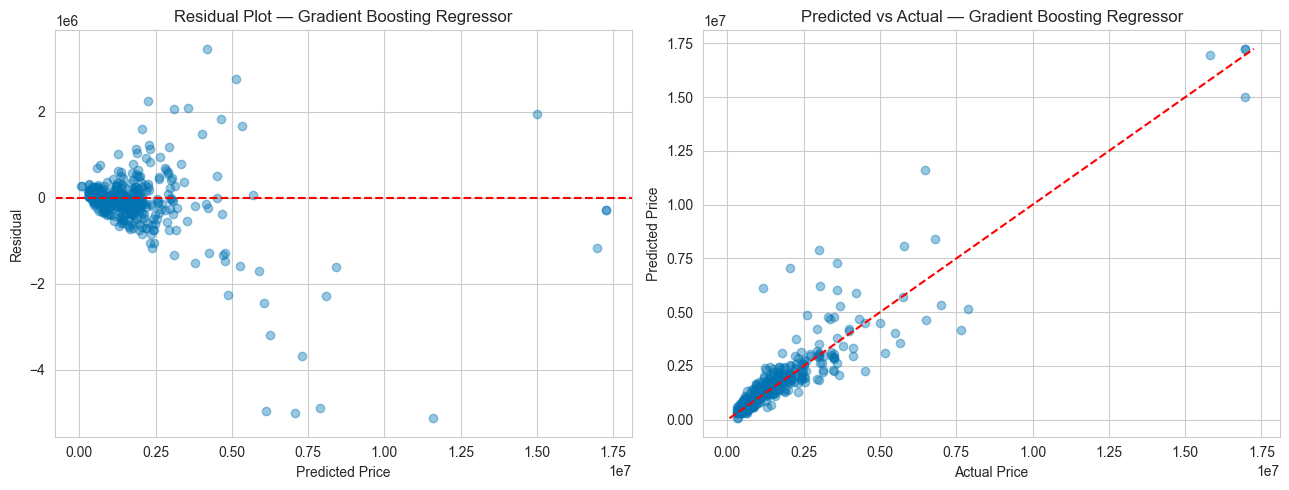

In [36]:
best_name = summary.index[0]
best_preds = results[best_name]['preds']
residuals = y_test.values - best_preds

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(best_preds, residuals, alpha=0.4)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted Price'); axes[0].set_ylabel('Residual')
axes[0].set_title(f'Residual Plot — {best_name}')

axes[1].scatter(y_test, best_preds, alpha=0.4)
lims = [min(y_test.min(), best_preds.min()), max(y_test.max(), best_preds.max())]
axes[1].plot(lims, lims, 'r--')
axes[1].set_xlabel('Actual Price'); axes[1].set_ylabel('Predicted Price')
axes[1].set_title(f'Predicted vs Actual — {best_name}')

plt.tight_layout()
plt.show()


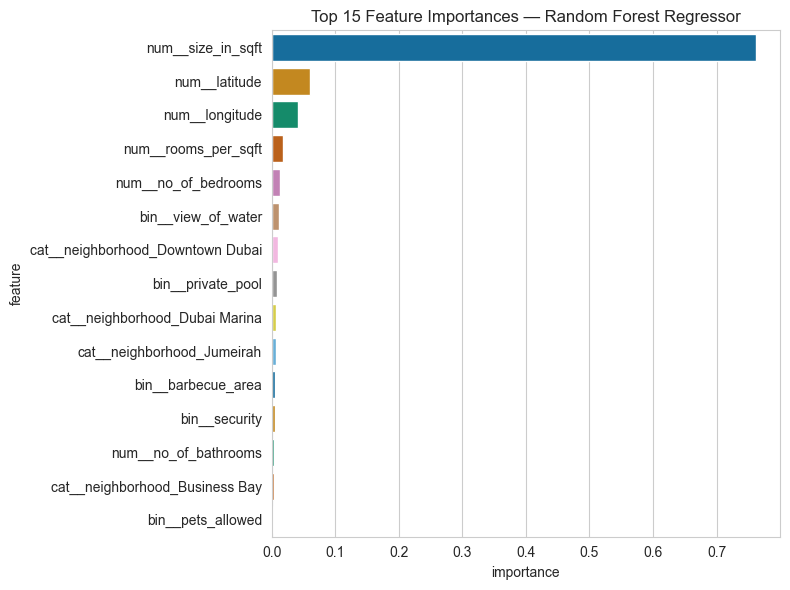

In [37]:
# Feature importance for a tree-based model (Random Forest)
rf_final = results['Random Forest Regressor']['model']
feature_names = rf_final.named_steps['prep'].get_feature_names_out()
importances = rf_final.named_steps['model'].feature_importances_

imp_df = pd.DataFrame({'feature': feature_names, 'importance': importances}) \
            .sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(8,6))
sns.barplot(data=imp_df, x='importance', y='feature', palette='colorblind')
plt.title('Top 15 Feature Importances — Random Forest Regressor')
plt.tight_layout()
plt.show()


## Summary

- Report which model achieved the best R² / lowest RMSE once run on the real dataset.
- Discuss whether the engineered `rooms_per_sqft` feature ranked highly in importance.
- Note any signs of overfitting (large train/test gap) for tree-based ensembles.
- This notebook covers Review 1 Section C (Regression Track) in full, and reuses the same
  cleaned `df` / preprocessing pattern for Classification Part A / Part B and Clustering notebooks.
